# Báo cáo tổng hợp cuối cùng

Notebook này gom kết quả từ các bước EDA, tiền xử lý, lựa chọn đặc trưng và mô hình hóa để tạo một bản tóm tắt chốt cuối cho dự án Abalone.

## 1. Import thư viện

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Xác định thư mục kết quả

In [ ]:
đường_dẫn_ứng_viên = [
    Path('../../outputs/metrics'),
    Path('../outputs/metrics'),
    Path('outputs/metrics'),
    Path('AbaloneAge/outputs/metrics'),
]

thư_mục_metrics = None
for p in đường_dẫn_ứng_viên:
    p_đầy_đủ = p.resolve()
    if p_đầy_đủ.exists():
        thư_mục_metrics = p_đầy_đủ
        break

if thư_mục_metrics is None:
    raise FileNotFoundError(
        'Không tìm thấy thư mục outputs/metrics. Hãy chạy các notebook trước trước khi mở báo cáo tổng hợp.'
    )

thư_mục_hình = thư_mục_metrics.parent / 'figures'
thư_mục_hình.mkdir(parents=True, exist_ok=True)

print('Thư mục metrics:', thư_mục_metrics)
print('Thư mục hình    :', thư_mục_hình)

Thu muc metrics: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\outputs\metrics
Thu muc hinh    : C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\outputs\figures


## 3. Đọc các summary đã lưu

In [ ]:
tập_tin_json = {
    'outlier': thư_mục_metrics / '01_eda_outlier_summary.json',
    'scaling': thư_mục_metrics / '02_preprocessing_scaling_summary.json',
    'kbest': thư_mục_metrics / '03_kbest_summary.json',
    'baseline': thư_mục_metrics / '03_baseline_summary.json',
    'rfe': thư_mục_metrics / '03_rfe_summary.json',
    'model_based': thư_mục_metrics / '03_model_based_summary.json',
    'compare_v2': thư_mục_metrics / '03_compare_v2_summary.json',
    'ensemble': thư_mục_metrics / '04_model_ensemble_try1_summary.json',
}

tổng_hợp_json = {}
for tên, p in tập_tin_json.items():
    if p.exists():
        with open(p, 'r', encoding='utf-8') as f:
            tổng_hợp_json[tên] = json.load(f)
    else:
        tổng_hợp_json[tên] = None

tổng_hợp_json

{'outlier': {'tong_so_dong': 4177,
  'tong_so_cot': 9,
  'so_dong_co_outlier': 153,
  'ty_le_dong_co_outlier_%': 3.66,
  'cot_nhieu_outlier_nhat': 'diameter',
  'ty_le_outlier_cot_cao_nhat_%': 1.41},
 'scaling': {'phuong_phap': 'scaling',
  'scaler_tot_nhat': 'minmax',
  'validation': {'scaler': 'minmax',
   'MAE': 1.6176846805984961,
   'RMSE': 2.20927142985101,
   'R2': 0.5135122789489468},
  'test': {'MAE': 1.5590950222105646,
   'RMSE': 2.175329190018127,
   'R2': 0.5389879864982308},
  'so_dac_trung_sau_scale': 10},
 'kbest': {'phuong_phap': 'select_k_best',
  'k_tot_nhat': 10,
  'val_tot_nhat': {'k': 10.0,
   'MAE': 1.6207319375785307,
   'RMSE': 2.2242728092687147,
   'R2': 0.5068831575504958},
  'test': {'MAE': 1.5450803650384637,
   'RMSE': 2.145675545394127,
   'R2': 0.5514711623514637}},
 'baseline': {'phương_pháp': 'baseline_thống_kê',
  'tổng_số_đặc_trưng': 8,
  'đặc_trưng_quan_trọng_nhất': 'shell_weight',
  'số_đặc_trưng_có_ý_nghĩa': 8},
 'rfe': {'phuong_phap': 'rfe',
  '

## 4. Đọc bảng metric đã lưu

In [ ]:
tập_tin_csv = {
    'scaling': thư_mục_metrics / '02_preprocessing_scaling_comparison.csv',
    'kbest': thư_mục_metrics / '03_kbest_k_comparison.csv',
    'rfe': thư_mục_metrics / '03_rfe_n_features_comparison.csv',
    'model_based': thư_mục_metrics / '03_model_based_model_metrics.csv',
    'compare_v2': thư_mục_metrics / '03_compare_v2_method_metrics.csv',
    'ensemble': thư_mục_metrics / '04_model_ensemble_try1_comparison.csv',
}

bảng_metrics = []
for tên, p in tập_tin_csv.items():
    if p.exists():
        df_tmp = pd.read_csv(p)
        df_tmp['nguồn'] = tên
        bảng_metrics.append(df_tmp)

if len(bảng_metrics) > 0:
    bảng_metrics = pd.concat(bảng_metrics, ignore_index=True)
else:
    bảng_metrics = pd.DataFrame()

bảng_metrics

,scaler,MAE,RMSE,R2,nguon,k,so_dac_trung,mo_hinh,phuong_phap
0,minmax,1.617685,2.209271,0.513512,scaling,NaN,NaN,NaN,NaN
1,robust,1.619604,2.221017,0.508326,scaling,NaN,NaN,NaN,NaN
2,standard,1.620732,2.224273,0.506883,scaling,NaN,NaN,NaN,NaN
3,NaN,1.620732,2.224273,0.506883,kbest,10.0,NaN,NaN,NaN
4,NaN,1.620749,2.224287,0.506877,kbest,9.0,NaN,NaN,NaN
5,NaN,1.694015,2.320446,0.463318,kbest,7.0,NaN,NaN,NaN
6,NaN,1.723273,2.345700,0.451573,kbest,5.0,NaN,NaN,NaN
7,NaN,1.766101,2.402035,0.424915,kbest,3.0,NaN,NaN,NaN
8,NaN,1.620118,2.223586,0.507188,rfe,NaN,9.0,NaN,NaN
9,NaN,1.620732,2.224273,0.506883,rfe,NaN,10.0,NaN,NaN


## 5. Tóm tắt dữ liệu và ngoại lệ

In [ ]:
def lấy_theo_nhiều_khóa(data, keys, mặc_định=None):
    for k in keys:
        if isinstance(data, dict) and k in data:
            return data[k]
    return mặc_định


tóm_tắt_dữ_liệu = []
if tổng_hợp_json.get('outlier') is not None:
    outlier = tổng_hợp_json['outlier']
    tóm_tắt_dữ_liệu.append({
        'hạng_mục': 'Tổng số dòng',
        'giá_trị': lấy_theo_nhiều_khóa(outlier, ['tổng_số_dòng', 'tong_so_dong']),
    })
    tóm_tắt_dữ_liệu.append({
        'hạng_mục': 'Số dòng có outlier',
        'giá_trị': lấy_theo_nhiều_khóa(outlier, ['số_dòng_có_outlier', 'so_dong_co_outlier']),
    })
    tóm_tắt_dữ_liệu.append({
        'hạng_mục': 'Tỷ lệ dòng có outlier (%)',
        'giá_trị': lấy_theo_nhiều_khóa(outlier, ['tỷ_lệ_dòng_có_outlier_%', 'ty_le_dong_co_outlier_%']),
    })
    tóm_tắt_dữ_liệu.append({
        'hạng_mục': 'Cột nhiều outlier nhất',
        'giá_trị': lấy_theo_nhiều_khóa(outlier, ['cột_nhiều_outlier_nhất', 'cot_nhieu_outlier_nhat']),
    })

bảng_tóm_tắt_dữ_liệu = pd.DataFrame(tóm_tắt_dữ_liệu)
bảng_tóm_tắt_dữ_liệu

,hang_muc,gia_tri
0,Tong so dong,4177
1,So dong co outlier,153
2,Ty le dong co outlier (%),3.66
3,Cot nhieu outlier nhat,diameter


## 6. So sánh tiền xử lý và lựa chọn đặc trưng

In [ ]:
bảng_tổng_hợp = []

if tổng_hợp_json.get('scaling') is not None:
    s = tổng_hợp_json['scaling']
    bảng_tổng_hợp.append({
        'bước': 'scaling',
        'tên_tốt_nhất': lấy_theo_nhiều_khóa(s, ['scaler_tốt_nhất', 'scaler_tot_nhat']),
        'MAE_test': s.get('test', {}).get('MAE'),
        'RMSE_test': s.get('test', {}).get('RMSE'),
        'R2_test': s.get('test', {}).get('R2'),
    })

if tổng_hợp_json.get('kbest') is not None:
    s = tổng_hợp_json['kbest']
    bảng_tổng_hợp.append({
        'bước': 'kbest',
        'tên_tốt_nhất': lấy_theo_nhiều_khóa(s, ['k_tốt_nhất', 'k_tot_nhat']),
        'MAE_test': s.get('test', {}).get('MAE'),
        'RMSE_test': s.get('test', {}).get('RMSE'),
        'R2_test': s.get('test', {}).get('R2'),
    })

if tổng_hợp_json.get('rfe') is not None:
    s = tổng_hợp_json['rfe']
    bảng_tổng_hợp.append({
        'bước': 'rfe',
        'tên_tốt_nhất': lấy_theo_nhiều_khóa(s, ['số_đặc_trưng_tốt_nhất', 'so_dac_trung_tot_nhat']),
        'MAE_test': s.get('test', {}).get('MAE'),
        'RMSE_test': s.get('test', {}).get('RMSE'),
        'R2_test': s.get('test', {}).get('R2'),
    })

if tổng_hợp_json.get('model_based') is not None:
    s = tổng_hợp_json['model_based']
    bảng_tổng_hợp.append({
        'bước': 'model_based',
        'tên_tốt_nhất': lấy_theo_nhiều_khóa(s, ['mô_hình_tốt_nhất', 'mo_hinh_tot_nhat']),
        'MAE_test': s.get('test', {}).get('MAE'),
        'RMSE_test': s.get('test', {}).get('RMSE'),
        'R2_test': s.get('test', {}).get('R2'),
    })

if tổng_hợp_json.get('ensemble') is not None:
    s = tổng_hợp_json['ensemble']
    bảng_tổng_hợp.append({
        'bước': 'ensemble',
        'tên_tốt_nhất': lấy_theo_nhiều_khóa(s, ['mô_hình_tốt_nhất', 'mo_hinh_tot_nhat']),
        'MAE_test': s.get('test', {}).get('MAE'),
        'RMSE_test': s.get('test', {}).get('RMSE'),
        'R2_test': s.get('test', {}).get('R2'),
    })

bảng_tổng_hợp_mô_hình = pd.DataFrame(bảng_tổng_hợp)
bảng_tổng_hợp_mô_hình

,buoc,ten_tot_nhat,MAE_test,RMSE_test,R2_test
0,scaling,minmax,1.559095,2.175329,0.538988
1,kbest,10,1.545080,2.145676,0.551471
2,rfe,9,1.545546,2.145583,0.551510
3,model_based,ridge,1.545080,2.145676,0.551471
4,ensemble,voting_ensemble,1.467828,2.055330,0.588447


## 7. Bảng metric tổng hợp

In [ ]:
if len(bảng_metrics) > 0:
    if 'mô_hình' not in bảng_metrics.columns and 'mo_hinh' in bảng_metrics.columns:
        bảng_metrics['mô_hình'] = bảng_metrics['mo_hinh']
    if 'mô_hình' not in bảng_metrics.columns and 'scaler' in bảng_metrics.columns:
        bảng_metrics['mô_hình'] = bảng_metrics['scaler']

    cột_tên = 'mô_hình' if 'mô_hình' in bảng_metrics.columns else bảng_metrics.columns[0]
    cột_mae = 'MAE' if 'MAE' in bảng_metrics.columns else None
    cột_rmse = 'RMSE' if 'RMSE' in bảng_metrics.columns else None
    cột_r2 = 'R2' if 'R2' in bảng_metrics.columns else None

    cột_hiển_thị = [cột_tên] + [c for c in [cột_mae, cột_rmse, cột_r2, 'nguồn'] if c is not None and c in bảng_metrics.columns]
    bảng_metrics_tinh = bảng_metrics[cột_hiển_thị].copy()
    bảng_metrics_tinh = bảng_metrics_tinh.sort_values(by=cột_rmse if cột_rmse else cột_tên, ascending=True)
    display(bảng_metrics_tinh)
else:
    bảng_metrics_tinh = pd.DataFrame()
    print('Không có file metric nào được nạp vào.')

,mo_hinh,MAE,RMSE,R2,nguon
16,NaN,1.545546,2.145583,0.551510,compare_v2
18,NaN,1.545080,2.145676,0.551471,compare_v2
17,NaN,1.545080,2.145676,0.551471,compare_v2
20,voting_ensemble,1.549685,2.192640,0.520809,ensemble
0,NaN,1.617685,2.209271,0.513512,scaling
1,NaN,1.619604,2.221017,0.508326,scaling
8,NaN,1.620118,2.223586,0.507188,rfe
3,NaN,1.620732,2.224273,0.506883,kbest
9,NaN,1.620732,2.224273,0.506883,rfe
21,ridge,1.620732,2.224273,0.506883,ensemble


## 8. Biểu đồ tổng quan

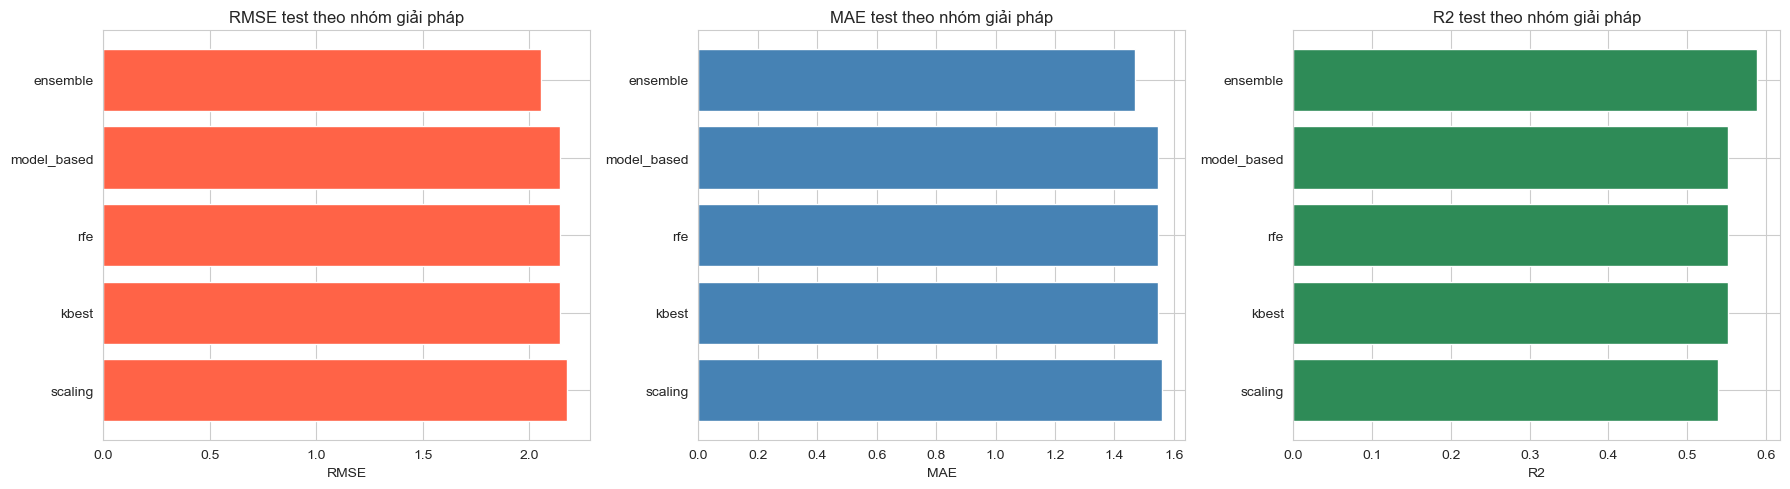

Da luu hinh: 06_report_summary_metrics.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if len(bảng_tổng_hợp_mô_hình) > 0:
    axes[0].barh(bảng_tổng_hợp_mô_hình['bước'], bảng_tổng_hợp_mô_hình['RMSE_test'], color='tomato')
    axes[0].set_title('RMSE test theo nhóm giải pháp')
    axes[0].set_xlabel('RMSE')

    axes[1].barh(bảng_tổng_hợp_mô_hình['bước'], bảng_tổng_hợp_mô_hình['MAE_test'], color='steelblue')
    axes[1].set_title('MAE test theo nhóm giải pháp')
    axes[1].set_xlabel('MAE')

    axes[2].barh(bảng_tổng_hợp_mô_hình['bước'], bảng_tổng_hợp_mô_hình['R2_test'], color='seagreen')
    axes[2].set_title('R2 test theo nhóm giải pháp')
    axes[2].set_xlabel('R2')
else:
    for ax in axes:
        ax.axis('off')

plt.tight_layout()
plt.savefig(thư_mục_hình / '06_report_summary_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print('Đã lưu hình: 06_report_summary_metrics.png')

## 9. Kết luận ngắn

In [ ]:
if len(bảng_tổng_hợp_mô_hình) > 0:
    hàng_tốt_nhất = bảng_tổng_hợp_mô_hình.sort_values(by='RMSE_test').iloc[0]
    print('Bước tốt nhất theo RMSE test:', hàng_tốt_nhất['bước'])
    print('Giá trị tốt nhất:', hàng_tốt_nhất['tên_tốt_nhất'])
    print(f"MAE  : {hàng_tốt_nhất['MAE_test']:.4f}")
    print(f"RMSE : {hàng_tốt_nhất['RMSE_test']:.4f}")
    print(f"R2   : {hàng_tốt_nhất['R2_test']:.4f}")
else:
    print('Chưa có dữ liệu tổng hợp để kết luận.')

Buoc tot nhat theo RMSE test: ensemble
Gia tri tot nhat: voting_ensemble
MAE  : 1.4678
RMSE : 2.0553
R2   : 0.5884


## 10. Lưu báo cáo tổng hợp

In [ ]:
thư_mục_báo_cáo = Path('../../reports/bao_cao_tieng_viet').resolve()
thư_mục_báo_cáo.mkdir(parents=True, exist_ok=True)

if len(bảng_tổng_hợp_mô_hình) > 0:
    bảng_tổng_hợp_mô_hình.to_csv(thư_mục_báo_cáo / '06_report_summary_model_overview.csv', index=False)

báo_cáo = {
    'tổng_quan': {
        'có_dữ_liệu_outlier': tổng_hợp_json.get('outlier') is not None,
        'có_dữ_liệu_scaling': tổng_hợp_json.get('scaling') is not None,
        'có_dữ_liệu_feature_selection': any(tổng_hợp_json.get(k) is not None for k in ['baseline', 'kbest', 'rfe', 'model_based', 'compare_v2']),
        'có_dữ_liệu_ensemble': tổng_hợp_json.get('ensemble') is not None,
    },
    'tổng_hợp': bảng_tổng_hợp_mô_hình.to_dict(orient='records') if len(bảng_tổng_hợp_mô_hình) > 0 else [],
    'kết_luận': {
        'bước_tốt_nhất': hàng_tốt_nhất['bước'] if len(bảng_tổng_hợp_mô_hình) > 0 else None,
        'giá_trị_tốt_nhất': hàng_tốt_nhất['tên_tốt_nhất'] if len(bảng_tổng_hợp_mô_hình) > 0 else None,
    } if len(bảng_tổng_hợp_mô_hình) > 0 else {},
}

with open(thư_mục_báo_cáo / '06_report_summary.json', 'w', encoding='utf-8') as f:
    json.dump(báo_cáo, f, ensure_ascii=False, indent=2)

print('Đã lưu: 06_report_summary_model_overview.csv')
print('Đã lưu: 06_report_summary.json')
print('Hoàn thành báo cáo tổng hợp.')

Da luu: 06_report_summary_model_overview.csv
Da luu: 06_report_summary.json
Hoan thanh bao cao tong hop.
